<a href="https://colab.research.google.com/github/RGarancs/applied-ai-academy-labs/blob/main/solutions/messy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Messy sales data (synthetic)

**Applied AI Academy — problem set with worked answers**

**Used in:** Lesson 7 — AI runs on data plumbing — readiness beats model choice  
**Rows:** 260  ·  **Source file:** `messy_sales_data.csv`



---
### How to use this notebook
Run the cells in order. Each problem is stated first, then solved, then the
answer is spelled out. For teaching, hide the solution cells and let the room
attempt the task before revealing them.

> The data loads straight from `appliedai.center` — nothing to upload.


## Setup

In [1]:
%matplotlib inline
import pandas as pd, numpy as np, os, urllib.request
import matplotlib, matplotlib.pyplot as plt
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

# Applied AI Academy chart style — calm, legible when projected
INK, ACCENT, CORE, BUILDER, DANGER = "#26214a", "#544d94", "#5b8a6e", "#a8845c", "#b05a5a"
matplotlib.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c9c4d8", "axes.labelcolor": INK, "axes.titlesize": 13,
    "axes.titleweight": "600", "axes.titlecolor": INK, "axes.titlepad": 14,
    "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "font.size": 10, "grid.color": "#e6e2ef", "axes.grid": True,
    "axes.axisbelow": True, "grid.linewidth": .8, "figure.facecolor": "white",
})

URL   = "https://appliedai.center/assets/datasets/messy_sales_data.csv"
LOCAL = "messy_sales_data.csv"
if not os.path.exists(LOCAL):
    print("Downloading", URL)
    urllib.request.urlretrieve(URL, LOCAL)

df = pd.read_csv(LOCAL, low_memory=False)
print("Shape:", df.shape)
df.head()

Shape: (260, 8)


,date,region,product,units,unit_price,discount_pct,sales_rep,notes
0,2026-01-12,baltics,Premium,48,196.38,10.0,NaN,renewal
1,2026-09-25,Nordics,Core,missing,120.62,NaN,Marta,NaN
2,2026-01-25,CEE,Enterprise,20,78.37,0.0,NaN,renewal
3,3/5/2026,Nordics,service,27,118.51,NaN,Lina,NaN
4,2026-02-17,Nordics,Core,38,202.23,0.0,Marta,renewal


## What is in the file

In [2]:
print("Columns and types:")
print(df.dtypes.to_string())
miss = df.isna().sum()
miss = miss[miss > 0]
print("\nMissing values:" if len(miss) else "\nNo missing values.")
if len(miss): print(miss.to_string())

Columns and types:
date                str
region              str
product             str
units               str
unit_price      float64
discount_pct    float64
sales_rep           str
notes               str

Missing values:
discount_pct    47
sales_rep       40
notes           54


---
## Problem 1 · Easy — describe

Find every data-quality problem before computing anything.

*Try it yourself first. The worked solution is below.*

In [3]:
print("Shape:", df.shape)
print("\nMissing values per column:\n", df.isna().sum())
print("\n'units' is stored as text — look why:")
print(df["units"].astype(str).str.strip().value_counts().head(12))
print("\nRegion spellings:", sorted(df["region"].dropna().unique().tolist()))
print("Product spellings:", sorted(df["product"].dropna().unique().tolist())[:12])
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (260, 8)

Missing values per column:
 date             0
region           0
product          0
units            0
unit_price       0
discount_pct    47
sales_rep       40
notes           54
dtype: int64

'units' is stored as text — look why:
units
missing    10
4          10
37         10
48          9
25          9
31          9
44          8
33          8
10          8
27          7
36          7
43          7
Name: count, dtype: int64

Region spellings: ['Baltics', 'CEE', 'Central Europe', 'Nordics', 'Nordics ', 'baltics']
Product spellings: ['Core', 'Enterprise', 'Premium', 'Service', 'service']

Duplicate rows: 0


---
## Problem 2 · Intermediate — build

Clean it, and state every decision you made.

*Try it yourself first. The worked solution is below.*

In [4]:
c = df.copy()

# 1. units: strip text, coerce to number, drop what cannot be salvaged
c["units_clean"] = pd.to_numeric(
    c["units"].astype(str).str.replace(r"[^0-9.\-]", "", regex=True).replace("", None),
    errors="coerce")

# 2. region / product: collapse casing and whitespace variants
c["region_clean"] = c["region"].astype(str).str.strip().str.title()
c["product_clean"] = c["product"].astype(str).str.strip().str.title()

# 3. dates: parse, keep failures visible
c["date_clean"] = pd.to_datetime(c["date"], errors="coerce", dayfirst=False)

# 4. discount: treat impossible values as missing rather than silently keeping them
c["discount_clean"] = c["discount_pct"].where(c["discount_pct"].between(0, 1))

print("Rows lost to unparseable units:", c["units_clean"].isna().sum())
print("Rows lost to unparseable dates:", c["date_clean"].isna().sum())
print("Impossible discounts blanked:  ", (c["discount_pct"].notna() & c["discount_clean"].isna()).sum())
print("\nRegions after cleaning:", sorted(c["region_clean"].unique().tolist()))

Rows lost to unparseable units: 10
Rows lost to unparseable dates: 14
Impossible discounts blanked:   129

Regions after cleaning: ['Baltics', 'Cee', 'Central Europe', 'Nordics']


---
## Problem 3 · Advanced — judge

Now compute revenue — and show how wrong the naive number was.

*Try it yourself first. The worked solution is below.*

In [5]:
c["revenue"] = c["units_clean"] * c["unit_price"] * (1 - c["discount_clean"].fillna(0))
total = c["revenue"].sum()
print(f"Total revenue (cleaned): EUR {total:,.0f}")

naive = pd.to_numeric(df["units"], errors="coerce") * df["unit_price"]
print(f"Naive total (no cleaning, no discount): EUR {naive.sum():,.0f}")
print(f"Difference: EUR {naive.sum() - total:,.0f}")

print("\nRevenue by region:")
print(c.groupby("region_clean")["revenue"].sum().sort_values(ascending=False).round(0))
print("\nEvery cleaning decision above changes this number. Document them.")

Total revenue (cleaned): EUR 765,993
Naive total (no cleaning, no discount): EUR 765,993
Difference: EUR 0

Revenue by region:
region_clean
Nordics           278605.0
Baltics           272948.0
Cee               127531.0
Central Europe     86909.0
Name: revenue, dtype: float64

Every cleaning decision above changes this number. Document them.


---
## Visual summary

The same answers, as pictures. These are what to project — a room reads a chart
far faster than it reads a table, and the shape of a result is usually the
argument you are actually making.

findfont: Failed to find font weight 600, now using 700.


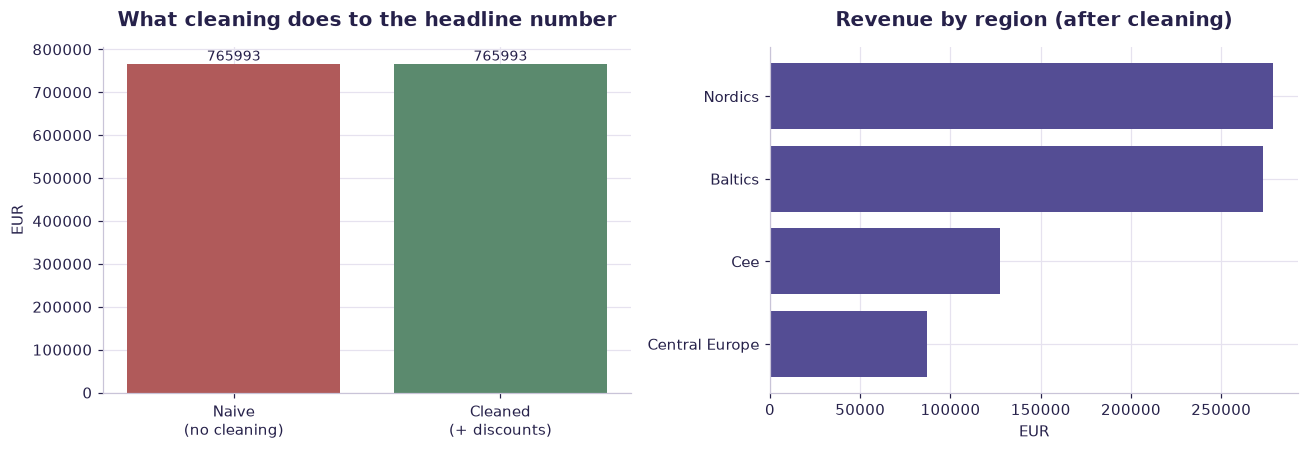

In [6]:
c = df.copy()
c["units_clean"] = pd.to_numeric(c["units"].astype(str).str.replace(r"[^0-9.\-]", "", regex=True).replace("", None), errors="coerce")
c["discount_clean"] = c["discount_pct"].where(c["discount_pct"].between(0, 1))
c["region_clean"] = c["region"].astype(str).str.strip().str.title()
c["revenue"] = c["units_clean"] * c["unit_price"] * (1 - c["discount_clean"].fillna(0))
naive = pd.to_numeric(df["units"], errors="coerce") * df["unit_price"]

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
vals = [naive.sum(), c["revenue"].sum()]
b = ax[0].bar(["Naive\n(no cleaning)", "Cleaned\n(+ discounts)"], vals, color=[DANGER, CORE])
ax[0].set_title("What cleaning does to the headline number"); ax[0].set_ylabel("EUR")
ax[0].bar_label(b, fmt="%.0f", fontsize=9)

reg = c.groupby("region_clean")["revenue"].sum().sort_values()
ax[1].barh(reg.index, reg.values, color=ACCENT)
ax[1].set_title("Revenue by region (after cleaning)"); ax[1].set_xlabel("EUR")
plt.tight_layout(); plt.show()

---
## Verified answer key

These are the numbers the academy ships for this dataset. They were computed
from this exact file — if your run disagrees, reconcile before teaching it.

1. Region spellings: baltics(45)/Baltics(41) · CEE(52)/Central Europe(35) · Nordics(87)
2. 40 missing reps · 10 "missing" units · 47 "n/a" discounts · 14 malformed dates
3. No exact duplicate rows (verify, don't assume)
4. Net revenue on the 250 clean-computable rows ≈ €728,000


---
## Teaching notes

* **Run the Easy problem live.** It sets the shared vocabulary and gets everyone
  looking at the same rows.
* **Let them fail on the Intermediate one.** The productive mistake is usually
  reaching for a model before checking the data.
* **Argue about the Advanced one.** It has no single right answer; it has a
  defensible one, and defending it is the skill being taught.
* **Always close on limitations.** Every dataset here has a real caveat —
  scrape bias, a tiny sample, a hindsight label. Naming it is the lesson.
* **Deliverable for learners:** Data readiness scorecard v1 + your cleaning decision log.

---
*Applied AI Academy · appliedai.center*
